## CustomerSegments 

##### import pandas as pd
def load_data():
    return pd.read_csv("SnapDeal.csv")
    
def clean_data(df):
    return df
    
df = load_data()
df = clean_data(df)
df.head()

In [10]:
def convert_frequency(x) :
    if x == "Multiple times a week":
        return 5
    elif x == "Once a week":
        return 4
    elif x == "Few times a month":
        return 3
    elif x == "Once a month":
        return 2
    elif x == "Less than once a month":
        return 1
    else:
        return 0
df["Purchase_Frequency_Num"] = df["Purchase_Frequency"].apply(convert_frequency)
    

In [12]:
def segment_customer(row):
    if row["Purchase_Frequency_Num"] >= 4 and row["Shopping_Satisfaction"] >= 4:
        return "Frequent_Buyer"
    elif row["Purchase_Frequency_Num"] >= 3 and row["Shopping_Satisfaction"] >= 3:
        return "Ocassional_Shopper"
    else:
        return "At-Risk_Customer"
df['Customer_Segment'] = df.apply(segment_customer, axis=1)

In [13]:
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction,Purchase_Frequency_Num,Customer_Segment
0,2023/06/07 11:06:40 PM GMT+5:30,59,Others,Once a week,Beauty and Personal Care,Yes,Few times a month,others,Multiple pages,4,...,No,1,Yes,3,3,Customer service,User interface of app,433348,4,Ocassional_Shopper
1,2023/06/06 7:08:47 PM GMT+5:30,48,Female,Once a month,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Rarely,categories,Multiple pages,1,...,Sometimes,1,No,5,2,.,.,735054,2,At-Risk_Customer
2,2023/06/08 9:39:30 PM GMT+5:30,57,Prefer not to say,Multiple times a week,Groceries and Gourmet Food,Sometimes,Rarely,Keyword,First page,2,...,No,5,Sometimes,3,3,Customer service,Product quality and accuracy,119350,5,Ocassional_Shopper
3,2023/06/07 9:22:24 PM GMT+5:30,30,Others,Few times a month,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,others,Multiple pages,2,...,Sometimes,4,Sometimes,4,5,Customer service,.,180686,3,Ocassional_Shopper
4,2023/06/06 7:21:26 PM GMT+5:30,51,Female,Once a month,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,Filter,First page,5,...,Sometimes,1,Yes,3,1,.,I don't have any problem with Amazon,538184,2,At-Risk_Customer


In [15]:
df['Customer_Segment'].value_counts()

Customer_Segment
At-Risk_Customer      514
Ocassional_Shopper    158
Frequent_Buyer        128
Name: count, dtype: int64

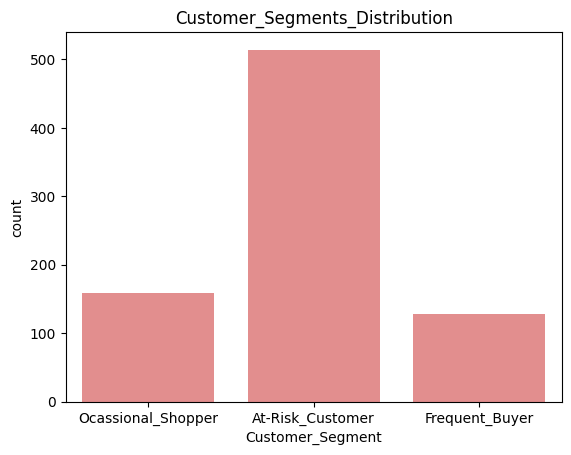

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x = 'Customer_Segment' , data = df,color = 'lightcoral')
plt.title("Customer_Segments_Distribution")
plt.show()

# Analyze Segments

# 1. Demographic comparison

In [20]:
print(df.groupby('Customer_Segment') ['age'].mean())
print(df.groupby('Customer_Segment') ['Gender'].value_counts())

Customer_Segment
At-Risk_Customer      36.352140
Frequent_Buyer        35.984375
Ocassional_Shopper    35.139241
Name: age, dtype: float64
Customer_Segment    Gender           
At-Risk_Customer    Male                 136
                    Female               131
                    Prefer not to say    128
                    Others               119
Frequent_Buyer      Male                  36
                    Others                35
                    Prefer not to say     30
                    Female                27
Ocassional_Shopper  Female                43
                    Male                  41
                    Others                38
                    Prefer not to say     36
Name: count, dtype: int64


# 2. Behavior Comparison

In [21]:
print(df.groupby('Customer_Segment') ['Cart_Abandonment_Factors'].value_counts())

Customer_Segment    Cart_Abandonment_Factors                  
At-Risk_Customer    Found a better price elsewhere                142
                    others                                        131
                    Changed my mind or no longer need the item    122
                    High shipping costs                           119
Frequent_Buyer      Found a better price elsewhere                 39
                    High shipping costs                            38
                    Changed my mind or no longer need the item     33
                    others                                         18
Ocassional_Shopper  others                                         47
                    Found a better price elsewhere                 38
                    High shipping costs                            37
                    Changed my mind or no longer need the item     36
Name: count, dtype: int64


In [23]:
from sklearn.cluster import KMeans

In [24]:
X = df[['Shopping_Satisfaction', 'Customer_Reviews_Importance']]

In [27]:
kmeans = KMeans(n_clusters= 3, random_state = 42)   #Apply K-Means
df['Cluster'] = kmeans. fit_predict (X)

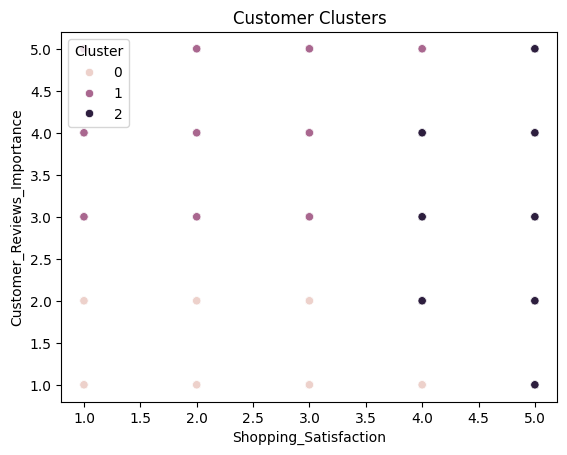

In [31]:
sns.scatterplot(
    x= df['Shopping_Satisfaction'],                # Visualize clusters
    y= df['Customer_Reviews_Importance'],
    hue= df['Cluster'] 
)
plt.title("Customer Clusters")
plt.show()


# Task 4 